In [282]:
# pandas is used for loading, cleaning, merging and analysing data
import pandas as pd

# numpy is used for numerical operations
import numpy as np

# matplotlib is used for creating graphs
import matplotlib.pyplot as plt

# seaborn is used to make statistical graphs more visually appealing
import seaborn as sns

# statsmodels is used for regression modelling
import statsmodels.api as sm

# Import packages for file paths and data loading
import os

# Import StandardScaler for standardised regression
from sklearn.preprocessing import StandardScaler

In [284]:
# Create file paths for the two datasets stored on Desktop
desktop = os.path.join(os.path.expanduser("~"), "Desktop")

happiness_path = os.path.join(desktop, "WHR25_Data_Figure_2.1v3.xlsx")
income_path = os.path.join(desktop, "CLASS_2025_10_07.xlsx")

# Load the World Happiness Report 2025 data file
# The latest available observations in this file are from 2024
happiness_df = pd.read_excel(
    happiness_path,
    sheet_name="Data for Figure 2.1 (2011–2024)"
)

# Keep only the latest available year in the happiness dataset
happiness_df = happiness_df[happiness_df["Year"] == 2024].copy()

# Load the World Bank income classification dataset
income_df = pd.read_excel(
    income_path,
    sheet_name="List of economies"
)

# Preview the happiness dataset
happiness_df.head()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2024,147,Afghanistan,1.364,1.301,1.427,0.649,0.000,0.155,0.000,0.075,0.135,0.348
13,2024,89,Albania,5.411,5.284,5.539,1.371,1.122,0.696,0.841,0.103,0.057,1.220
26,2024,84,Algeria,5.571,5.469,5.674,1.315,1.363,0.782,0.522,0.057,0.219,1.313
45,2024,42,Argentina,6.397,6.302,6.492,1.504,1.622,0.579,0.824,0.048,0.083,1.736
58,2024,87,Armenia,5.494,5.391,5.596,1.391,1.349,0.828,0.786,0.032,0.158,0.950


In [285]:
# Display the first few rows of the happiness dataset
happiness_df.head()


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2024,147,Afghanistan,1.364,1.301,1.427,0.649,0.000,0.155,0.000,0.075,0.135,0.348
13,2024,89,Albania,5.411,5.284,5.539,1.371,1.122,0.696,0.841,0.103,0.057,1.220
26,2024,84,Algeria,5.571,5.469,5.674,1.315,1.363,0.782,0.522,0.057,0.219,1.313
45,2024,42,Argentina,6.397,6.302,6.492,1.504,1.622,0.579,0.824,0.048,0.083,1.736
58,2024,87,Armenia,5.494,5.391,5.596,1.391,1.349,0.828,0.786,0.032,0.158,0.950


In [288]:
# Display the first few rows of the World Bank income group dataset
income_df.head()

,Economy,Code,Region,Income group,Lending category
0,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA
1,Albania,ALB,Europe & Central Asia,Upper middle income,IBRD
2,Algeria,DZA,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income,IBRD
3,American Samoa,ASM,East Asia & Pacific,High income,NaN
4,Andorra,AND,Europe & Central Asia,High income,NaN


In [289]:
# Check the column names in the happiness dataset
print(happiness_df.columns)

Index(['Year', 'Rank', 'Country name', 'Life evaluation (3-year average)',
       'Lower whisker', 'Upper whisker', 'Explained by: Log GDP per capita',
       'Explained by: Social support', 'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='object')


In [292]:
# Check the column names in the World Bank dataset
print(income_df.columns)

Index(['Economy', 'Code', 'Region', 'Income group', 'Lending category'], dtype='object')


In [294]:
# Check basic information about the happiness dataset
# This helps us see data types and missing values
happiness_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147 entries, 0 to 1956
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        147 non-null    int64  
 1   Rank                                        147 non-null    int64  
 2   Country name                                147 non-null    object 
 3   Life evaluation (3-year average)            147 non-null    float64
 4   Lower whisker                               147 non-null    float64
 5   Upper whisker                               147 non-null    float64
 6   Explained by: Log GDP per capita            147 non-null    float64
 7   Explained by: Social support                147 non-null    float64
 8   Explained by: Healthy life expectancy       146 non-null    float64
 9   Explained by: Freedom to make life choices  146 non-null    float64
 10  Explained by: Gene

In [296]:
# Select only the happiness variables needed for this project
happiness_clean = happiness_df[
    ["Country name","Life evaluation (3-year average)","Explained by: Log GDP per capita",
     "Explained by: Social support","Explained by: Healthy life expectancy",
     "Explained by: Freedom to make life choices", "Explained by: Generosity", 
     "Explained by: Perceptions of corruption"]].copy()

# Rename long column names into shorter names for easier analysis
happiness_clean = happiness_clean.rename(
    columns={"Country name": "Country", "Life evaluation (3-year average)": "Happiness Score",
             "Explained by: Log GDP per capita": "Economy","Explained by: Social support": "Family",
             "Explained by: Healthy life expectancy": "Health","Explained by: Freedom to make life choices": "Freedom",
             "Explained by: Generosity": "Generosity","Explained by: Perceptions of corruption": "Corruption"})

# Select only the income classification variables needed for this project
income_clean = income_df[["Economy","Code","Region","Income group"]].copy()

# Rename the World Bank region column to make it clearer after merging
income_clean = income_clean.rename(
    columns={"Region": "World Bank Region"})

# Preview the cleaned happiness dataset
happiness_clean.head()

,Country,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption
0,Afghanistan,1.364,0.649,0.000,0.155,0.000,0.075,0.135
13,Albania,5.411,1.371,1.122,0.696,0.841,0.103,0.057
26,Algeria,5.571,1.315,1.363,0.782,0.522,0.057,0.219
45,Argentina,6.397,1.504,1.622,0.579,0.824,0.048,0.083
58,Armenia,5.494,1.391,1.349,0.828,0.786,0.032,0.158


In [298]:
# Display cleaned World Bank income group data
income_clean.head()

,Economy,Code,World Bank Region,Income group
0,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income
1,Albania,ALB,Europe & Central Asia,Upper middle income
2,Algeria,DZA,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income
3,American Samoa,ASM,East Asia & Pacific,High income
4,Andorra,AND,Europe & Central Asia,High income


In [300]:
# Some country names are written differently in the two datasets
# This dictionary corrects those differences before merging
name_corrections = {
    "Czechia": "Czechia",
    "Czech Republic": "Czechia",
    "Slovakia": "Slovak Republic",
    "Russia": "Russian Federation",
    "South Korea": "Korea, Rep.",
    "North Korea": "Korea, Dem. People's Rep.",
    "Hong Kong S.A.R. of China": "Hong Kong SAR, China",
    "Hong Kong S.A.R., China": "Hong Kong SAR, China",
    "Macedonia": "North Macedonia",
    "Kyrgyzstan": "Kyrgyz Republic",
    "State of Palestine": "West Bank and Gaza",
    "Palestinian Territories": "West Bank and Gaza",
    "Egypt": "Egypt, Arab Rep.",
    "Iran": "Iran, Islamic Rep.",
    "Congo (Brazzaville)": "Congo, Rep.",
    "Congo (Kinshasa)": "Congo, Dem. Rep.",
    "Yemen": "Yemen, Rep.",
    "Syria": "Syrian Arab Republic",
    "Turkey": "Türkiye",
    "Türkiye": "Türkiye",
    "Somalia": "Somalia, Fed. Rep.",
    "Ivory Coast": "Côte d’Ivoire",
    "Venezuela": "Venezuela, RB",
    "Gambia": "Gambia, The",
    "Laos": "Lao PDR"
}

# Create a new country column for merging with the World Bank dataset
happiness_clean["Country_merge"] = happiness_clean["Country"].replace(name_corrections)

# Check the original and corrected country names
happiness_clean[["Country", "Country_merge"]].head()

,Country,Country_merge
0,Afghanistan,Afghanistan
13,Albania,Albania
26,Algeria,Algeria
45,Argentina,Argentina
58,Armenia,Armenia


In [302]:
# Merge the happiness dataset with the World Bank income group dataset
# The merge is based on corrected country names
merged_df = happiness_clean.merge(
    income_clean,
    left_on="Country_merge",
    right_on="Economy",
    how="left",
    suffixes=("_happiness", "_worldbank")
)

# Preview the merged dataset
merged_df.head()

,Country,Happiness Score,Economy_happiness,Family,Health,Freedom,Generosity,Corruption,Country_merge,Economy_worldbank,Code,World Bank Region,Income group
0,Afghanistan,1.364,0.649,0.000,0.155,0.000,0.075,0.135,Afghanistan,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income
1,Albania,5.411,1.371,1.122,0.696,0.841,0.103,0.057,Albania,Albania,ALB,Europe & Central Asia,Upper middle income
2,Algeria,5.571,1.315,1.363,0.782,0.522,0.057,0.219,Algeria,Algeria,DZA,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income
3,Argentina,6.397,1.504,1.622,0.579,0.824,0.048,0.083,Argentina,Argentina,ARG,Latin America & Caribbean,Upper middle income
4,Armenia,5.494,1.391,1.349,0.828,0.786,0.032,0.158,Armenia,Armenia,ARM,Europe & Central Asia,Upper middle income


In [304]:
# Rename columns after merging to avoid confusion
# Economy_happiness means GDP contribution from the happiness dataset
# Economy_worldbank means country/economy name from the World Bank dataset
merged_df = merged_df.rename(
    columns={
        "Economy_happiness": "Economy",
        "Economy_worldbank": "World Bank Country"
    }
)

# Check the new column names
print(merged_df.columns)

Index(['Country', 'Happiness Score', 'Economy', 'Family', 'Health', 'Freedom',
       'Generosity', 'Corruption', 'Country_merge', 'World Bank Country',
       'Code', 'World Bank Region', 'Income group'],
      dtype='object')


In [306]:
# Find countries that did not match with the World Bank income dataset
unmatched = merged_df[merged_df["Income group"].isna()][
    ["Country", "Country_merge"]
]

# Display unmatched countries
unmatched

,Country,Country_merge
27,Congo,Congo
35,DR Congo,DR Congo
41,Ethiopia,Ethiopia
53,Hong Kong SAR of China,Hong Kong SAR of China
109,Republic of Korea,Republic of Korea
110,Republic of Moldova,Republic of Moldova
127,Taiwan Province of China,Taiwan Province of China
142,Venezuela,"Venezuela, RB"
143,Viet Nam,Viet Nam


In [308]:
# Count how many countries do not have an income group after merging
print("Number of countries without income group:", merged_df["Income group"].isna().sum())

Number of countries without income group: 9


In [310]:
# Count missing values in each column of the merged dataset
merged_df.isna().sum()

Country               0
Happiness Score       0
Economy               0
Family                0
Health                1
Freedom               1
Generosity            0
Corruption            1
Country_merge         0
World Bank Country    7
Code                  7
World Bank Region     7
Income group          9
dtype: int64

In [312]:
# Drop rows with missing values in the variables used for analysis
# This avoids errors in regression models and plots
analysis_df = merged_df.dropna(
    subset=["Happiness Score","Economy","Family","Health","Freedom","Generosity","Corruption","Income group"]).copy()

# Check final analysis dataset
analysis_df.shape

(135, 13)

In [314]:
# Summary statistics help us understand the scale and spread of each variable
analysis_df[["Happiness Score","Economy","Family","Health","Freedom","Generosity","Corruption"]].describe()

,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption
count,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000
mean,5.593733,1.334237,1.333370,0.548904,0.751267,0.114511,0.145815
std,1.175449,0.376651,0.357588,0.218705,0.180341,0.060794,0.114453
min,1.364000,0.535000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.651000,1.051000,1.131000,0.414000,0.661500,0.067000,0.065500
50%,5.870000,1.380000,1.444000,0.551000,0.768000,0.111000,0.118000
75%,6.528500,1.648000,1.607000,0.712500,0.885500,0.151500,0.183000
max,7.736000,2.028000,1.840000,0.935000,1.018000,0.323000,0.522000


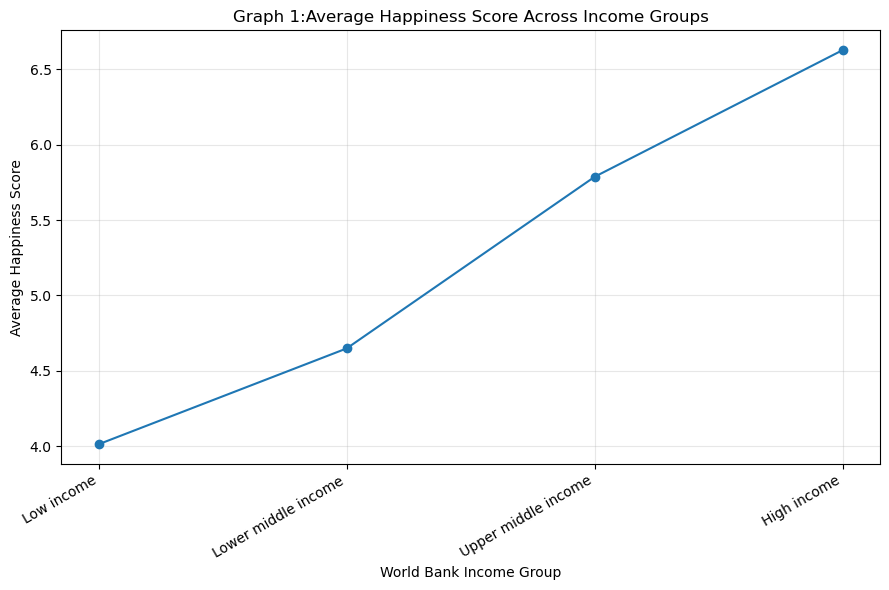

In [316]:

# Graph 1: Line graph of average happiness by income group

# Define the correct order of income groups
# This makes the line go from low income to high income
income_order = [
    "Low income",
    "Lower middle income",
    "Upper middle income",
    "High income"
]

# Calculate the average happiness score for each income group
line_data = analysis_df.groupby("Income group")["Happiness Score"].mean()

# Reorder the income groups in a logical economic order
line_data = line_data.reindex(income_order)

# Set graph size
plt.figure(figsize=(9, 6))

# Create line graph with markers
plt.plot(
    line_data.index,
    line_data.values,
    marker="o"
)

# Add title and axis labels
plt.title("Graph 1:Average Happiness Score Across Income Groups")
plt.xlabel("World Bank Income Group")
plt.ylabel("Average Happiness Score")

# Rotate x-axis labels to make them easier to read
plt.xticks(rotation=30, ha="right")

# Add grid lines to make comparison easier
plt.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()

# Show graph
plt.show()

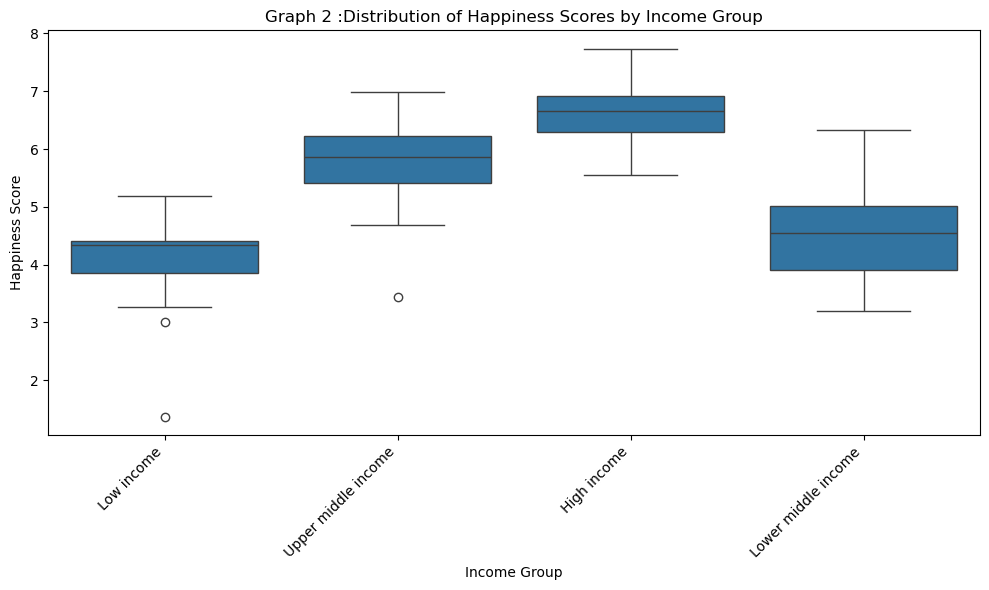

In [318]:

# Graph 2: Box plot of happiness score by income group

# Set graph size
plt.figure(figsize=(10, 6))

# Create box plot
sns.boxplot(
    data=analysis_df,
    x="Income group",
    y="Happiness Score"
)

# Add title and labels
plt.title("Graph 2 :Distribution of Happiness Scores by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Happiness Score")

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")

# Improve layout
plt.tight_layout()

# Show graph
plt.show()

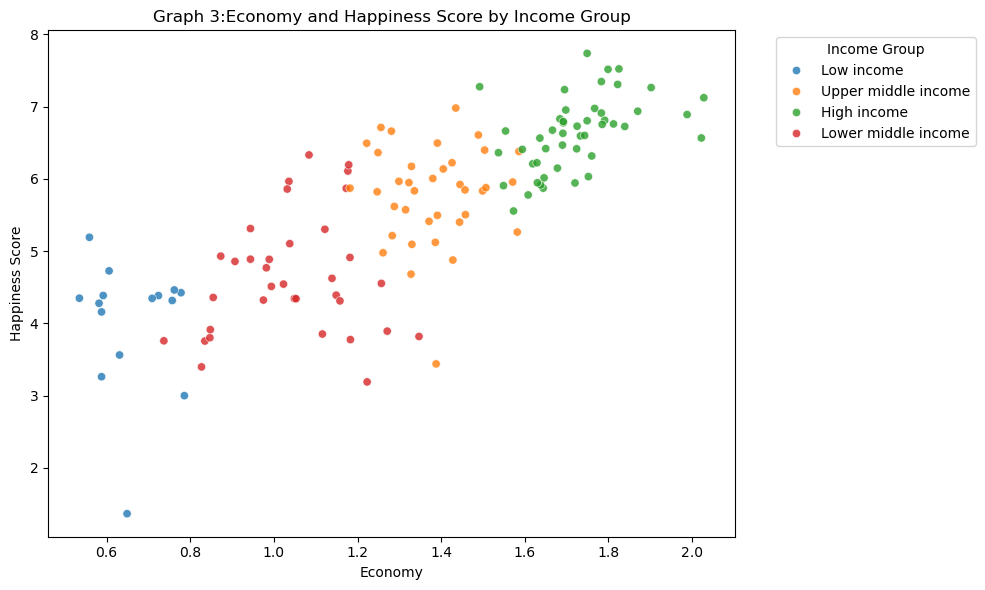

In [320]:
# Graph 3: Scatter plot coloured by income group

# Set graph size
plt.figure(figsize=(10, 6))

# Create scatter plot with different colours for each income group
sns.scatterplot(
    data=analysis_df,
    x="Economy",
    y="Happiness Score",
    hue="Income group",
    alpha=0.8
)

# Add title and labels
plt.title("Graph 3:Economy and Happiness Score by Income Group")
plt.xlabel("Economy")
plt.ylabel("Happiness Score")

# Move legend outside the plot
plt.legend(title="Income Group", bbox_to_anchor=(1.05, 1), loc="upper left")

# Improve layout
plt.tight_layout()

# Show graph
plt.show()

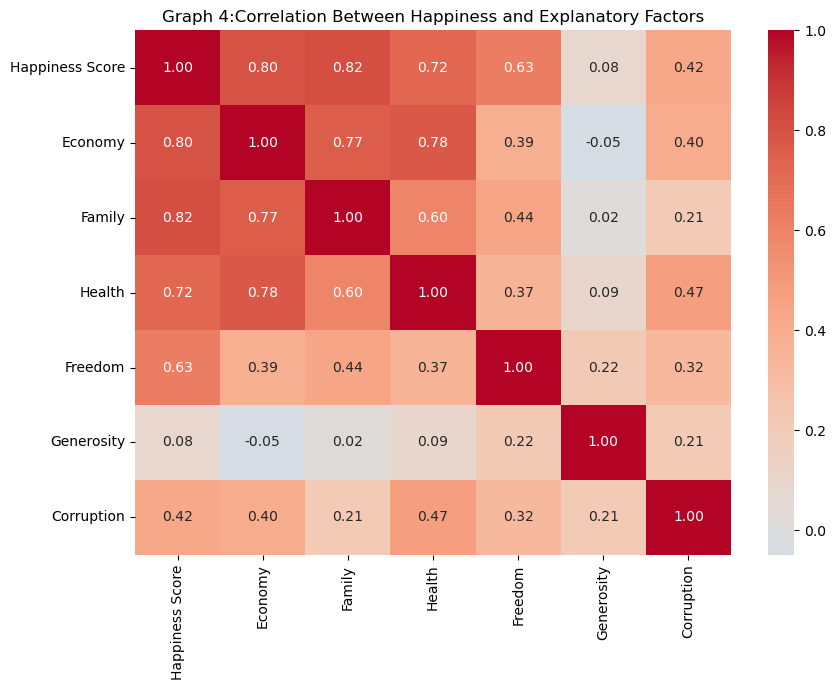

In [321]:
# Graph 4: Correlation heatmap

# Select numerical variables for correlation analysis
corr_vars = analysis_df[
    ["Happiness Score","Economy","Family","Health",
     "Freedom","Generosity","Corruption"]]

# Calculate correlation matrix
corr_matrix = corr_vars.corr()

# Set graph size
plt.figure(figsize=(9, 7))

# Create heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

# Add title
plt.title("Graph 4:Correlation Between Happiness and Explanatory Factors")

# Improve layout
plt.tight_layout()

# Show graph
plt.show()

In [322]:
#  Regression model

# Define the dependent variable
# This is the outcome we want to explain
y = analysis_df["Happiness Score"]

# Define independent variables
# These are the factors that may explain happiness
X = analysis_df[
    ["Economy","Family","Health","Freedom","Generosity","Corruption" ]]

# Add a constant term to the regression model
# This is needed for statsmodels OLS regression
X = sm.add_constant(X)

# Run OLS regression
model = sm.OLS(y, X).fit()

# Print regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Happiness Score   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     109.9
Date:                Fri, 15 May 2026   Prob (F-statistic):           4.83e-48
Time:                        07:56:51   Log-Likelihood:                -90.249
No. Observations:                 135   AIC:                             194.5
Df Residuals:                     128   BIC:                             214.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9662      0.216      4.470      0.0

In [323]:
# Standardised regression coefficient plot

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Define dependent variable
y = analysis_df["Happiness Score"]

# Define explanatory variables
X = analysis_df[
    ["Economy","Family","Health","Freedom", "Generosity","Corruption"]]

# Standardise the explanatory variables
# This puts all variables on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert the scaled data back into a dataframe
X_scaled = pd.DataFrame(X_scaled,columns=X.columns,index=X.index)

# Add a constant term for the regression
X_scaled = sm.add_constant(X_scaled)

# Run OLS regression using standardised variables
standardised_model = sm.OLS(y, X_scaled).fit()

# Print regression results
print(standardised_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Happiness Score   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     109.9
Date:                Fri, 15 May 2026   Prob (F-statistic):           4.83e-48
Time:                        07:56:51   Log-Likelihood:                -90.249
No. Observations:                 135   AIC:                             194.5
Df Residuals:                     128   BIC:                             214.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.5937      0.042    134.034      0.0

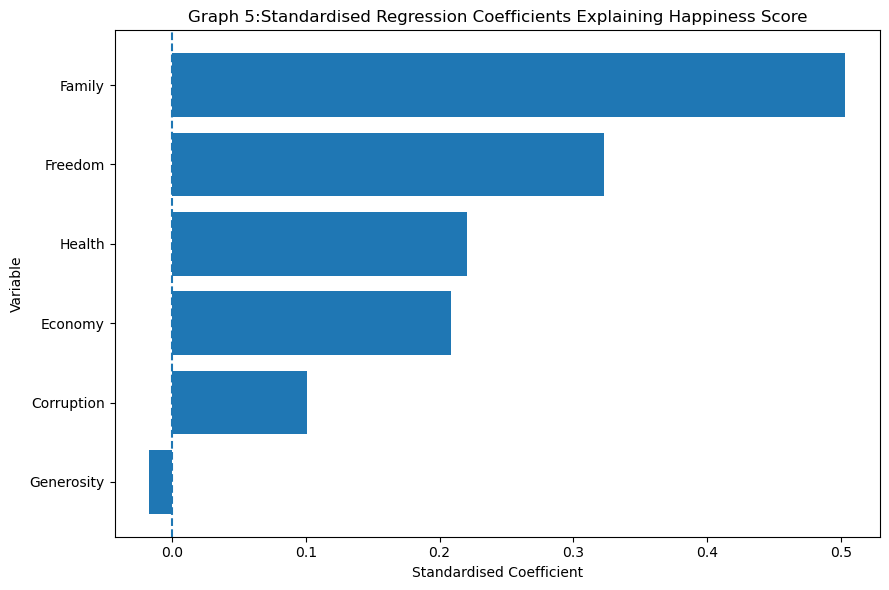

In [328]:
# Graph 5: Standardised regression coefficients


# Extract coefficients, excluding the constant
coefficients = standardised_model.params.drop("const")

# Create dataframe for plotting
coef_df = pd.DataFrame({
    "Variable": coefficients.index,
    "Coefficient": coefficients.values
})

# Sort by coefficient size
coef_df = coef_df.sort_values("Coefficient")

# Set graph size
plt.figure(figsize=(9, 6))

# Create horizontal bar chart
plt.barh(coef_df["Variable"], coef_df["Coefficient"])

# Add vertical line at zero
plt.axvline(0, linestyle="--")

# Add title and labels
plt.title("Graph 5:Standardised Regression Coefficients Explaining Happiness Score")
plt.xlabel("Standardised Coefficient")
plt.ylabel("Variable")

# Improve layout
plt.tight_layout()

# Show graph
plt.show()